In [1]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms, models
from tqdm.auto import tqdm
from pathlib import Path
from timeit import default_timer as timer
import os
from torchvision.transforms import v2

from pytorch_grad_cam import GradCAM, GradCAMPlusPlus, HiResCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image
from pathlib import Path

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [4]:

# 2. Define Transforms
# ResNet50 requires 224x224 and ImageNet normalization
train_transform = v2.Compose([
    transforms.RandomResizedCrop(224), ##########
    transforms.RandomHorizontalFlip(),
    transforms.TrivialAugmentWide(), 
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

test_transform = v2.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# 3. Data Loading (Fixing the Transform Bug)
image_path = Path("data/")

# Create two identical dataset instances with DIFFERENT transforms
full_dataset_augmented = datasets.ImageFolder(root=image_path, transform=train_transform)
full_dataset_clean = datasets.ImageFolder(root=image_path, transform=test_transform)

# Generate indices for the split
dataset_size = len(full_dataset_augmented)
train_size = int(0.8 * dataset_size)
indices = torch.randperm(dataset_size, generator=torch.Generator().manual_seed(42)).tolist()

# Create Subsets using the indices
# This ensures train uses augmentations and test stays clean
train_dataset = Subset(full_dataset_augmented, indices[:train_size])
test_dataset = Subset(full_dataset_clean, indices[train_size:])

# Create Dataloaders (Setting num_workers > 0 to saturate GPU)
BATCH_SIZE = 128
NUM_WORKERS =16

train_dataloader = DataLoader(
    train_dataset,
    batch_size=128,
    shuffle=True,
    num_workers=16,
    pin_memory=True,
    persistent_workers=True,
    prefetch_factor=4
)

test_dataloader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, 
                             num_workers=NUM_WORKERS, pin_memory=True)

# 4. Enhanced Model (Transfer Learning + Fine-Tuning)
def create_enhanced_model(output_shape, device):
    weights = models.ResNet50_Weights.DEFAULT
    model = models.resnet50(weights=weights)
    
    # Freeze all layers first
    for param in model.parameters():
        param.requires_grad = False
        
    # UNFREEZE Layer 3, 4: This allows the model to learn complex food-specific shapes
    for param in model.layer3.parameters():
        param.requires_grad = True
    for param in model.layer4.parameters():
        param.requires_grad = True
        
    model.fc = nn.Sequential(
        nn.Dropout(p=0.5),
        nn.Linear(model.fc.in_features, 512),
        nn.ReLU(),
        nn.Linear(512, output_shape)
    )
    return model.to(device)

OUTPUT_SHAPE = len(full_dataset_augmented.classes)
model_resnet = create_enhanced_model(OUTPUT_SHAPE, device)

# 5. Functions for Training and Testing
def train_step(model, dataloader, loss_fn, optimizer, device):
    model.train()
    train_loss, train_acc = 0, 0
    for X, y in dataloader:
        X, y = X.to(device), y.to(device) # Move to GPU
        y_pred = model(X)
        loss = loss_fn(y_pred, y)
        train_loss += loss.item()
        optimizer.zero_grad()

        loss.backward()

        optimizer.step()
        #scheduler.step()

        train_acc += (torch.argmax(y_pred, dim=1) == y).sum().item()/len(y_pred)
    return train_loss / len(dataloader), train_acc / len(dataloader)

def test_step(model, dataloader, loss_fn, device):
    model.eval()
    test_loss, test_acc = 0, 0
    with torch.inference_mode():
        for X, y in dataloader:
            X, y = X.to(device), y.to(device)
            test_pred = model(X)
            test_loss += loss_fn(test_pred, y).item()
            test_acc += (torch.argmax(test_pred, dim=1) == y).sum().item()/len(test_pred)
    return test_loss / len(dataloader), test_acc / len(dataloader)


## 1. Generic Model Factory

In [5]:
import copy
import time
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
from torchvision import models
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

In [6]:
device = "cuda" if torch.cuda.is_available() else "cpu"

if device == "cuda":
    torch.backends.cudnn.benchmark = True            # auto-tunes conv kernels
    torch.backends.cuda.matmul.allow_tf32 = True      # TF32 matmuls
    torch.backends.cudnn.allow_tf32 = True            # TF32 convs
    print(f"Using GPU: {torch.cuda.get_device_name(0)}")
    # Note: RTX 5090 is sm_120 (Blackwell). If you hit a "CUDA error: no
    # kernel image is available" message, your PyTorch build is too old —
    # install a build whose CUDA toolkit supports sm_120.
else:
    print("CUDA not available — training will run on CPU (very slow).")

USE_AMP = device == "cuda"
AMP_DTYPE = torch.bfloat16  # bf16 needs no GradScaler and Blackwell handles it natively


Using GPU: NVIDIA GeForce RTX 5090 Laptop GPU


In [7]:
# 1. Model factory — one entry per architecture

def create_model(model_name: str, output_shape: int, device: str) -> nn.Module:
    """Build a pretrained backbone, freeze most of it, unfreeze the last
    block(s), and swap in a fresh classification head."""
    model_name = model_name.lower()

    if model_name == "resnet50":
        model = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
        for p in model.parameters():
            p.requires_grad = False
        for p in model.layer3.parameters():
            p.requires_grad = True
        for p in model.layer4.parameters():
            p.requires_grad = True
        model.fc = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(model.fc.in_features, 512),
            nn.ReLU(),
            nn.Linear(512, output_shape),
        )

    elif model_name == "resnet18":
        model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
        for p in model.parameters():
            p.requires_grad = False
        for p in model.layer3.parameters():
            p.requires_grad = True
        for p in model.layer4.parameters():
            p.requires_grad = True
        model.fc = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(model.fc.in_features, 256),
            nn.ReLU(),
            nn.Linear(256, output_shape),
        )

    elif model_name == "efficientnet_b0":
        model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.DEFAULT)
        for p in model.parameters():
            p.requires_grad = False
        for p in model.features[-3:].parameters():
            p.requires_grad = True
        in_features = model.classifier[1].in_features
        model.classifier = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(in_features, 512),
            nn.ReLU(),
            nn.Linear(512, output_shape),
        )

    elif model_name == "mobilenet_v3_large":
        model = models.mobilenet_v3_large(weights=models.MobileNet_V3_Large_Weights.DEFAULT)
        for p in model.parameters():
            p.requires_grad = False
        for p in model.features[-4:].parameters():
            p.requires_grad = True
        in_features = model.classifier[0].in_features
        model.classifier = nn.Sequential(
            nn.Linear(in_features, 512),
            nn.Hardswish(),
            nn.Dropout(0.5),
            nn.Linear(512, output_shape),
        )

    elif model_name == "convnext_tiny":
        model = models.convnext_tiny(weights=models.ConvNeXt_Tiny_Weights.DEFAULT)
        for p in model.parameters():
            p.requires_grad = False
        for p in model.features[-2:].parameters():
            p.requires_grad = True
        in_features = model.classifier[2].in_features
        model.classifier[2] = nn.Linear(in_features, output_shape)

    elif model_name == "swin_t":
        model = models.swin_t(weights=models.Swin_T_Weights.DEFAULT)
        for p in model.parameters():
            p.requires_grad = False
        for p in model.features[-2:].parameters():
            p.requires_grad = True
        model.head = nn.Linear(model.head.in_features, output_shape)

    else:
        raise ValueError(
            f"Unknown model_name '{model_name}'. Choose from: resnet50, resnet18, "
            "efficientnet_b0, mobilenet_v3_large, convnext_tiny, swin_t"
        )

    return model.to(device, memory_format=torch.channels_last)




## 2. Optimized Training Function

In [8]:
# 2. Train / test steps — AMP (bf16) + channels_last for GPU throughput

def train_step(model, dataloader, loss_fn, optimizer, device):
    model.train()
    train_loss, train_acc = 0.0, 0.0
    for X, y in dataloader:
        X = X.to(device, memory_format=torch.channels_last, non_blocking=True)
        y = y.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)
        with torch.autocast(device_type="cuda", dtype=AMP_DTYPE, enabled=USE_AMP):
            y_pred = model(X)
            loss = loss_fn(y_pred, y)

        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        train_acc += (torch.argmax(y_pred, dim=1) == y).sum().item() / len(y_pred)

    return train_loss / len(dataloader), train_acc / len(dataloader)


def test_step(model, dataloader, loss_fn, device):
    model.eval()
    test_loss, test_acc = 0.0, 0.0
    with torch.inference_mode():
        for X, y in dataloader:
            X = X.to(device, memory_format=torch.channels_last, non_blocking=True)
            y = y.to(device, non_blocking=True)
            with torch.autocast(device_type="cuda", dtype=AMP_DTYPE, enabled=USE_AMP):
                test_pred = model(X)
                loss = loss_fn(test_pred, y)
            test_loss += loss.item()
            test_acc += (torch.argmax(test_pred, dim=1) == y).sum().item() / len(test_pred)
    return test_loss / len(dataloader), test_acc / len(dataloader)



In [9]:

@torch.inference_mode()
def get_predictions(model, dataloader, device):
    """Run inference over the full dataloader, return (y_true, y_pred) arrays."""
    model.eval()
    all_preds, all_labels = [], []
    for X, y in dataloader:
        X = X.to(device, memory_format=torch.channels_last, non_blocking=True)
        with torch.autocast(device_type="cuda", dtype=AMP_DTYPE, enabled=USE_AMP):
            logits = model(X)
        all_preds.extend(torch.argmax(logits, dim=1).cpu().numpy())
        all_labels.extend(y.numpy())
    return np.array(all_labels), np.array(all_preds)


# ---------------------------------------------------------------------------
# 3. Train + evaluate ONE model, checkpointing the best epoch
# ---------------------------------------------------------------------------
def train_and_evaluate(
    model_name,
    output_shape,
    class_names,
    train_dataloader,
    test_dataloader,
    device,
    epochs=15,
    lr=1e-4,
    save_root="saved_models",
    use_compile=True,
):
    print(f"\n{'=' * 70}\nTraining: {model_name}\n{'=' * 70}")

    model = create_model(model_name, output_shape, device)
    """
    if use_compile and device == "cuda":
        try:
            model = torch.compile(model)
        except Exception as e:
            print(f"  torch.compile unavailable, continuing eager: {e}")
    """

    loss_fn = nn.CrossEntropyLoss()
    optimizer = torch.optim.AdamW(
        filter(lambda p: p.requires_grad, model.parameters()), lr=lr, weight_decay=1e-4
    )
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

    save_dir = Path(save_root) / model_name
    save_dir.mkdir(parents=True, exist_ok=True)
    best_path = save_dir / "best_model.pth"

    best_acc = 0.0
    best_state = None
    history = {"train_loss": [], "train_acc": [], "test_loss": [], "test_acc": []}

    start = time.time()
    for epoch in range(epochs):
        train_loss, train_acc = train_step(model, train_dataloader, loss_fn, optimizer, device)
        test_loss, test_acc = test_step(model, test_dataloader, loss_fn, device)
        scheduler.step()

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["test_loss"].append(test_loss)
        history["test_acc"].append(test_acc)

        print(
            f"[{model_name}] Epoch {epoch + 1}/{epochs} | "
            f"train_loss={train_loss:.4f} train_acc={train_acc:.4f} | "
            f"test_loss={test_loss:.4f} test_acc={test_acc:.4f}"
        )

        if test_acc > best_acc:
            best_acc = test_acc
            best_state = copy.deepcopy(model.state_dict())
            torch.save(
                {
                    "model_name": model_name,
                    "state_dict": best_state,
                    "test_acc": best_acc,
                    "class_names": class_names,
                    "epoch": epoch + 1,
                },
                best_path,
            )
            print(f"  -> new best ({best_acc:.4f}) saved to {best_path}")

    elapsed_min = (time.time() - start) / 60
    print(f"Finished {model_name} in {elapsed_min:.1f} min | best test_acc={best_acc:.4f}")

    # Reload best weights before scoring, so the report matches the checkpoint
    model.load_state_dict(best_state)
    y_true, y_pred = get_predictions(model, test_dataloader, device)

    report = classification_report(y_true, y_pred, target_names=class_names, digits=4)
    cm = confusion_matrix(y_true, y_pred)

    del model
    torch.cuda.empty_cache()

    return {
        "model_name": model_name,
        "best_acc": best_acc,
        "history": history,
        "report": report,
        "confusion_matrix": cm,
        "checkpoint_path": str(best_path),
        "train_time_min": elapsed_min,
    }



## 3. Compare All Models

In [10]:
# 4. Compare several models

def compare_models(
    model_names,
    output_shape,
    class_names,
    train_dataloader,
    test_dataloader,
    device,
    epochs=15,
    lr=1e-4,
    lr_overrides: dict | None = None,
    save_root="saved_models",
):
    lr_overrides = lr_overrides or {}
    results = {}
    for name in model_names:
        results[name] = train_and_evaluate(
            name,
            output_shape,
            class_names,
            train_dataloader,
            test_dataloader,
            device,
            epochs=epochs,
            lr=lr_overrides.get(name, lr),
            save_root=save_root,
        )
    display_comparison(results, class_names, save_root)
    return results



# Display ranking

In [11]:
# 5. Display: summary table, accuracy bar chart, per-model report + CM
def display_comparison(results, class_names, save_root="saved_models"):
    print("\n" + "=" * 70)
    print("MODEL COMPARISON SUMMARY")
    print("=" * 70)
    print(f"{'Model':<22}{'Best Test Acc':<18}{'Train Time (min)':<18}")
    ranked = sorted(results.items(), key=lambda kv: kv[1]["best_acc"], reverse=True)
    for name, r in ranked:
        print(f"{name:<22}{r['best_acc'] * 100:<18.2f}{r['train_time_min']:<18.1f}")

    # Accuracy bar chart
    names = [n for n, _ in ranked]
    accs = [results[n]["best_acc"] * 100 for n in names]
    plt.figure(figsize=(8, 5))
    bars = plt.bar(names, accs, color="steelblue")
    plt.ylabel("Best Test Accuracy (%)")
    plt.title("Model Comparison — Waste Classification")
    plt.xticks(rotation=30, ha="right")
    plt.ylim(0, 100)
    for bar, acc in zip(bars, accs):
        plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1, f"{acc:.2f}%", ha="center")
    plt.tight_layout()
    plt.savefig(f"{save_root}/model_comparison_accuracy.png", dpi=150)
    plt.show()

    # Per-model classification report + confusion matrix
    for name, r in results.items():
        print(f"\n{'-' * 70}\nClassification Report: {name}\n{'-' * 70}")
        print(r["report"])

        cm = r["confusion_matrix"]
        n = len(class_names)
        plt.figure(figsize=(max(6, n * 0.6), max(5, n * 0.5)))
        sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
        plt.xlabel("Predicted")
        plt.ylabel("True")
        plt.title(f"Confusion Matrix — {name}")
        plt.tight_layout()
        cm_path = Path(save_root) / name / "confusion_matrix.png"
        plt.savefig(cm_path, dpi=150)
        plt.show()
        print(f"Confusion matrix saved to {cm_path}")





Training: resnet50
[resnet50] Epoch 1/10 | train_loss=1.0676 train_acc=0.5687 | test_loss=0.5935 test_acc=0.8282
  -> new best (0.8282) saved to saved_models\resnet50\best_model.pth
[resnet50] Epoch 2/10 | train_loss=0.4691 train_acc=0.8488 | test_loss=0.2576 test_acc=0.9102
  -> new best (0.9102) saved to saved_models\resnet50\best_model.pth
[resnet50] Epoch 3/10 | train_loss=0.2710 train_acc=0.9006 | test_loss=0.1652 test_acc=0.9295
  -> new best (0.9295) saved to saved_models\resnet50\best_model.pth
[resnet50] Epoch 4/10 | train_loss=0.2101 train_acc=0.9228 | test_loss=0.1709 test_acc=0.9284
[resnet50] Epoch 5/10 | train_loss=0.1756 train_acc=0.9332 | test_loss=0.1291 test_acc=0.9495
  -> new best (0.9495) saved to saved_models\resnet50\best_model.pth
[resnet50] Epoch 6/10 | train_loss=0.1356 train_acc=0.9531 | test_loss=0.1212 test_acc=0.9508
  -> new best (0.9508) saved to saved_models\resnet50\best_model.pth
[resnet50] Epoch 7/10 | train_loss=0.1235 train_acc=0.9580 | test_loss=

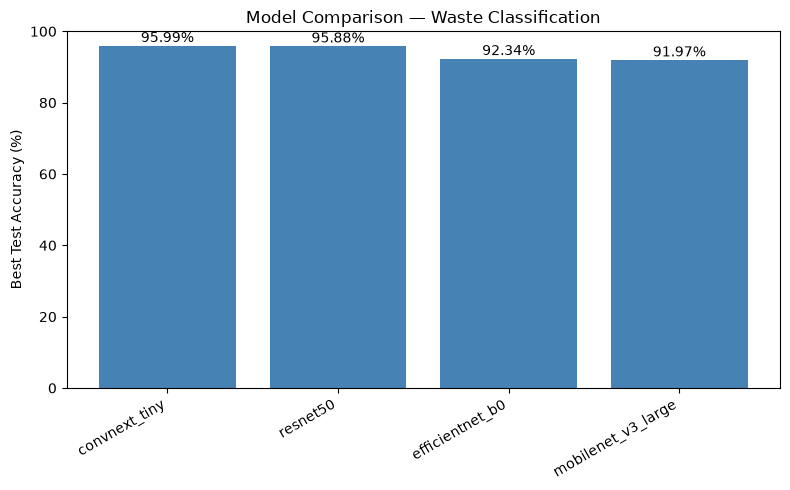


----------------------------------------------------------------------
Classification Report: resnet50
----------------------------------------------------------------------
              precision    recall  f1-score   support

       Glass     0.9635    0.9496    0.9565       139
       Metal     0.9683    0.9511    0.9596       225
     Organik     0.9766    1.0000    0.9882       167
     Plastic     0.9321    0.9406    0.9364       219

    accuracy                         0.9587       750
   macro avg     0.9601    0.9603    0.9602       750
weighted avg     0.9587    0.9587    0.9586       750



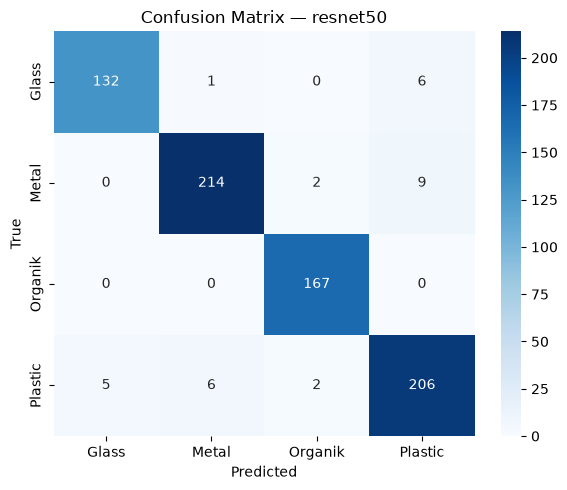

Confusion matrix saved to saved_models\resnet50\confusion_matrix.png

----------------------------------------------------------------------
Classification Report: efficientnet_b0
----------------------------------------------------------------------
              precision    recall  f1-score   support

       Glass     0.9535    0.8849    0.9179       139
       Metal     0.9075    0.9156    0.9115       225
     Organik     0.9822    0.9940    0.9881       167
     Plastic     0.8800    0.9041    0.8919       219

    accuracy                         0.9240       750
   macro avg     0.9308    0.9246    0.9274       750
weighted avg     0.9246    0.9240    0.9240       750



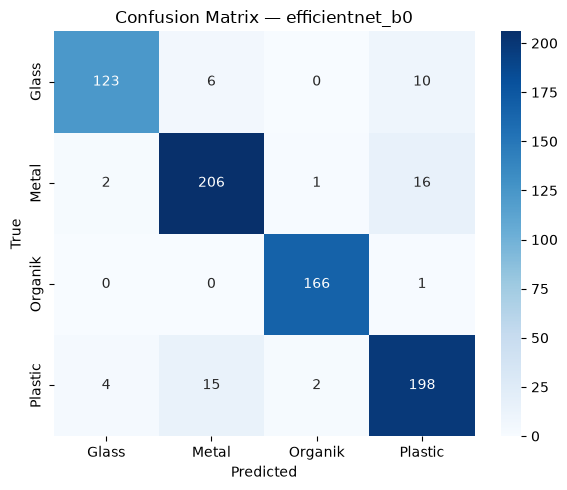

Confusion matrix saved to saved_models\efficientnet_b0\confusion_matrix.png

----------------------------------------------------------------------
Classification Report: mobilenet_v3_large
----------------------------------------------------------------------
              precision    recall  f1-score   support

       Glass     0.9333    0.9065    0.9197       139
       Metal     0.8978    0.8978    0.8978       225
     Organik     0.9940    0.9880    0.9910       167
     Plastic     0.8795    0.8995    0.8894       219

    accuracy                         0.9200       750
   macro avg     0.9261    0.9230    0.9245       750
weighted avg     0.9204    0.9200    0.9201       750



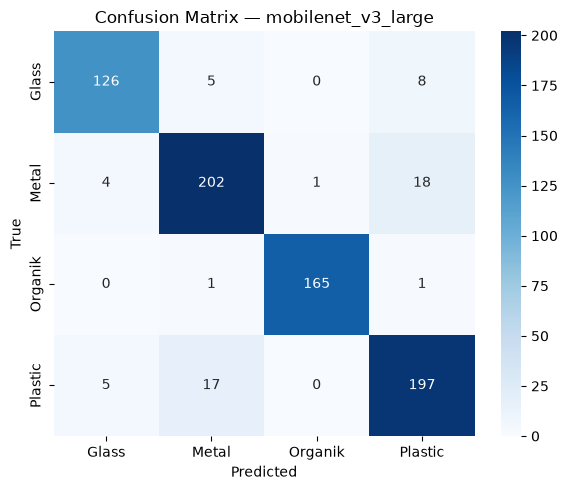

Confusion matrix saved to saved_models\mobilenet_v3_large\confusion_matrix.png

----------------------------------------------------------------------
Classification Report: convnext_tiny
----------------------------------------------------------------------
              precision    recall  f1-score   support

       Glass     0.9500    0.9568    0.9534       139
       Metal     0.9814    0.9378    0.9591       225
     Organik     0.9940    1.0000    0.9970       167
     Plastic     0.9207    0.9543    0.9372       219

    accuracy                         0.9600       750
   macro avg     0.9615    0.9622    0.9617       750
weighted avg     0.9607    0.9600    0.9601       750



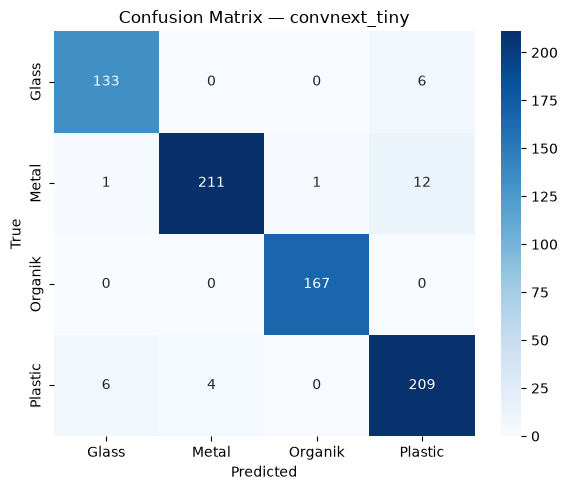

Confusion matrix saved to saved_models\convnext_tiny\confusion_matrix.png


In [13]:
# 6. Run it
if __name__ == "__main__":
    # Uses variables from your existing data-loading cell:
    #   full_dataset_augmented, train_dataloader, test_dataloader, device
    class_names = full_dataset_augmented.classes
    output_shape = len(class_names)

    MODEL_NAMES = [
        "resnet50",
        "efficientnet_b0",
        "mobilenet_v3_large",
        "convnext_tiny",
        # "resnet18", "swin_t",   # uncomment to include
    ]

    results = compare_models(
        model_names=MODEL_NAMES,
        output_shape=output_shape,
        class_names=class_names,
        train_dataloader=train_dataloader,
        test_dataloader=test_dataloader,
        device=device,
        epochs=10,
        lr=1e-4,
        save_root="saved_models",
    )


Loaded 'resnet50' | checkpoint test_acc=0.9644 | classes=['Glass', 'Metal', 'Organik', 'Plastic']


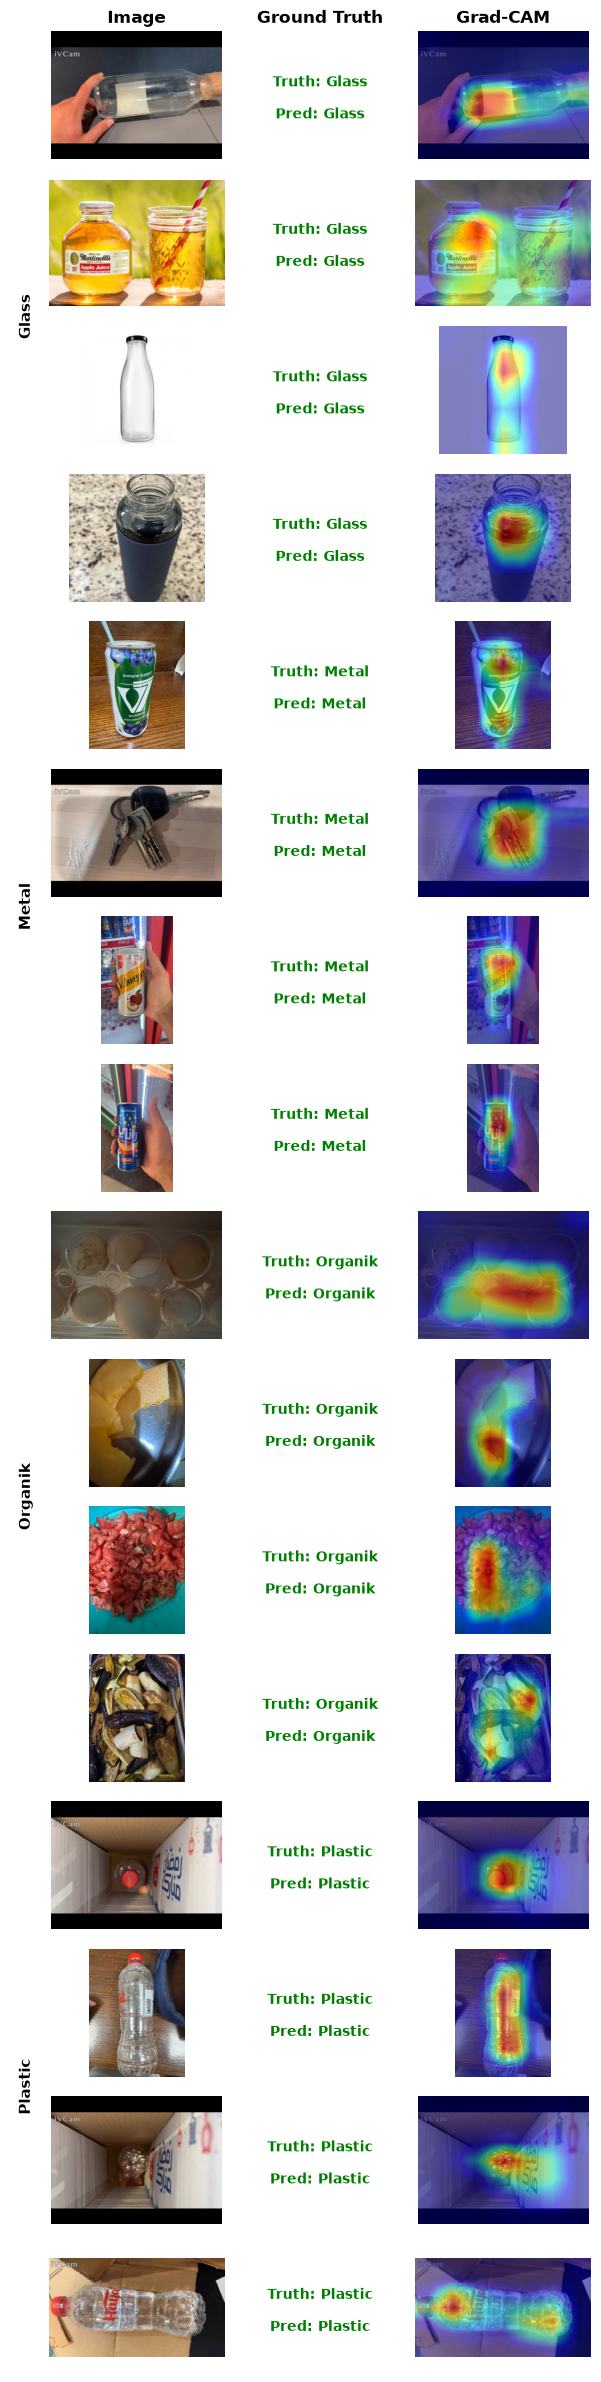

Saved Grad-CAM grid (16 images) to 'gradcam_results.png'


In [14]:
"""
Grad-CAM visualization for the trained ResNet50 waste classifier.

Produces a grid like:
    [Class label] | Original Image | Truth/Pred (green=correct, red=wrong) | Grad-CAM overlay

"""

import os
import random

import matplotlib.gridspec as gridspec
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from PIL import Image
from torchvision import models, transforms

# ---------------------------------------------------------------------------
# CONFIG — edit these to match your setup
# ---------------------------------------------------------------------------
CHECKPOINT_PATH = "saved_models_resnet50/resnet50/best_model.pth"   # from train_and_evaluate()
TEST_DIR = "test"                # contains Glass/, Metal/, Organik/, Plastic/ subfolders
IMAGES_PER_CLASS = 4             # how many sample images to show per class
IMG_SIZE = 224                   # must match the size your model was trained on
OUTPUT_PATH = "gradcam_results.png"
SEED = 42

# ImageNet normalization — change only if your training pipeline used something else
NORM_MEAN = [0.485, 0.456, 0.406]
NORM_STD = [0.229, 0.224, 0.225]

device = "cuda" if torch.cuda.is_available() else "cpu"

# ---------------------------------------------------------------------------
# 1. Rebuild the exact architecture used in training, then load the checkpoint
# ---------------------------------------------------------------------------
def create_model(output_shape: int) -> nn.Module:
    model = models.resnet50(weights=None)  # weights come from the checkpoint, not ImageNet
    model.fc = nn.Sequential(
        nn.Dropout(0.5),
        nn.Linear(model.fc.in_features, 512),
        nn.ReLU(),
        nn.Linear(512, output_shape),
    )
    return model


checkpoint = torch.load(CHECKPOINT_PATH, map_location=device)
class_names = checkpoint["class_names"]

model = create_model(len(class_names))
model.load_state_dict(checkpoint["state_dict"])
model.to(device)
model.eval()

print(
    f"Loaded '{checkpoint['model_name']}' | "
    f"checkpoint test_acc={checkpoint['test_acc']:.4f} | classes={class_names}"
)

# ---------------------------------------------------------------------------
# 2. Grad-CAM implementation (hooks on the last block of layer4)
# ---------------------------------------------------------------------------
class GradCAM:
    def __init__(self, model: nn.Module, target_layer: nn.Module):
        self.model = model
        self.activations = None
        self.gradients = None
        target_layer.register_forward_hook(self._save_activation)
        target_layer.register_full_backward_hook(self._save_gradient)

    def _save_activation(self, module, inp, out):
        self.activations = out.detach()

    def _save_gradient(self, module, grad_in, grad_out):
        self.gradients = grad_out[0].detach()

    def __call__(self, x: torch.Tensor, class_idx: int | None = None):
        self.model.zero_grad(set_to_none=True)
        output = self.model(x)  # [1, num_classes]

        if class_idx is None:
            class_idx = int(output.argmax(dim=1).item())

        score = output[0, class_idx]
        score.backward()

        gradients = self.gradients[0]      # [C, H, W]
        activations = self.activations[0]  # [C, H, W]
        weights = gradients.mean(dim=(1, 2))  # global-average-pooled gradients, [C]

        cam = torch.einsum("c,chw->hw", weights, activations)
        cam = F.relu(cam)
        cam = cam - cam.min()
        cam = cam / (cam.max() + 1e-8)

        probs = output.softmax(dim=1)[0]
        return cam.cpu().numpy(), class_idx, float(probs[class_idx].item())


# For ResNet50, the last residual block of layer4 gives the standard Grad-CAM target
target_layer = model.layer4[-1]
gradcam = GradCAM(model, target_layer)

# ---------------------------------------------------------------------------
# 3. Preprocessing — must match your test-time transform
# ---------------------------------------------------------------------------
preprocess = transforms.Compose(
    [
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize(mean=NORM_MEAN, std=NORM_STD),
    ]
)


def overlay_heatmap(cam: np.ndarray, original_img: Image.Image, alpha: float = 0.5) -> np.ndarray:
    """Resize the low-res CAM to the original image size and blend as a jet heatmap."""
    cam_img = Image.fromarray((cam * 255).astype(np.uint8)).resize(original_img.size, Image.BILINEAR)
    cam_resized = np.array(cam_img) / 255.0

    heatmap = plt.get_cmap("jet")(cam_resized)[:, :, :3]
    orig = np.array(original_img.convert("RGB")) / 255.0

    overlay = alpha * heatmap + (1 - alpha) * orig
    return np.clip(overlay, 0, 1)


# ---------------------------------------------------------------------------
# 4. Collect sample images, grouped by class (so rows stay grouped like the reference)
# ---------------------------------------------------------------------------
random.seed(SEED)

IMG_EXTS = (".jpg", ".jpeg", ".png", ".bmp", ".webp")
samples = []          # (path, true_class_name)
group_bounds = []     # (class_name, start_row, end_row) inclusive, for the left-side label

for cls in class_names:
    cls_dir = os.path.join(TEST_DIR, cls)
    if not os.path.isdir(cls_dir):
        print(f"Warning: '{cls_dir}' not found, skipping class '{cls}'")
        continue

    files = [f for f in os.listdir(cls_dir) if f.lower().endswith(IMG_EXTS)]
    if not files:
        print(f"Warning: no images found in '{cls_dir}'")
        continue

    chosen = random.sample(files, min(IMAGES_PER_CLASS, len(files)))
    start_row = len(samples)
    for f in chosen:
        samples.append((os.path.join(cls_dir, f), cls))
    end_row = len(samples) - 1
    group_bounds.append((cls, start_row, end_row))

if not samples:
    raise RuntimeError(f"No images found under '{TEST_DIR}'. Check TEST_DIR / folder structure.")

n_rows = len(samples)

# ---------------------------------------------------------------------------
# 5. Run Grad-CAM on every sample and build the figure
# ---------------------------------------------------------------------------
fig = plt.figure(figsize=(7.5, 1.9 * n_rows))
gs = gridspec.GridSpec(
    n_rows, 4, width_ratios=[0.18, 1, 1, 1], wspace=0.05, hspace=0.15, figure=fig
)

col_titles = ["Image", "Ground Truth", "Grad-CAM"]

for row, (path, true_cls) in enumerate(samples):
    img_pil = Image.open(path).convert("RGB")
    x = preprocess(img_pil).unsqueeze(0).to(device)

    cam, pred_idx, confidence = gradcam(x)
    pred_cls = class_names[pred_idx]
    correct = pred_cls == true_cls
    color = "green" if correct else "red"

    overlay = overlay_heatmap(cam, img_pil)

    # Column 1: original image
    ax_img = fig.add_subplot(gs[row, 1])
    ax_img.imshow(img_pil)
    ax_img.axis("off")

    # Column 2: Truth / Pred text
    ax_txt = fig.add_subplot(gs[row, 2])
    ax_txt.axis("off")
    ax_txt.text(
        0.5, 0.6, f"Truth: {true_cls}",
        ha="center", va="center", fontsize=10, color=color, fontweight="bold",
        transform=ax_txt.transAxes,
    )
    ax_txt.text(
        0.5, 0.35, f"Pred: {pred_cls}",
        ha="center", va="center", fontsize=10, color=color, fontweight="bold",
        transform=ax_txt.transAxes,
    )

    # Column 3: Grad-CAM overlay
    ax_cam = fig.add_subplot(gs[row, 3])
    ax_cam.imshow(overlay)
    ax_cam.axis("off")

    if row == 0:
        ax_img.set_title(col_titles[0], fontsize=12, fontweight="bold")
        ax_txt.set_title(col_titles[1], fontsize=12, fontweight="bold")
        ax_cam.set_title(col_titles[2], fontsize=12, fontweight="bold")

# Left-side rotated class labels spanning each group of rows
for cls, start_row, end_row in group_bounds:
    ax_label = fig.add_subplot(gs[start_row : end_row + 1, 0])
    ax_label.axis("off")
    ax_label.text(
        0.5, 0.5, cls, ha="center", va="center", rotation=90,
        fontsize=11, fontweight="bold", transform=ax_label.transAxes,
    )

plt.savefig(OUTPUT_PATH, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved Grad-CAM grid ({n_rows} images) to '{OUTPUT_PATH}'")